In [1]:
import torch
import torchaudio
import librosa
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Audio
import random
import math
import ast
import os

In [2]:
def plot_waveform(waveform, sample_rate, title="Waveform", xlim=None, ylim=None):
  waveform = waveform.numpy()

  num_channels, num_frames = waveform.shape
  time_axis = torch.arange(0, num_frames) / sample_rate

  figure, axes = plt.subplots(num_channels, 1)
  if num_channels == 1:
    axes = [axes]
  for c in range(num_channels):
    axes[c].plot(time_axis, waveform[c], linewidth=1)
    axes[c].grid(True)
    if num_channels > 1:
      axes[c].set_ylabel(f'Channel {c+1}')
    if xlim:
      axes[c].set_xlim(xlim)
    if ylim:
      axes[c].set_ylim(ylim)
  figure.suptitle(title)
  plt.show(block=False)

def plot_spectrogram(specgram, title=None, ylabel="freq_bin", ax=None):
    if ax is None:
        _, ax = plt.subplots(1, 1)
    if title is not None:
        ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.imshow(librosa.power_to_db(specgram), origin="lower", aspect="auto", interpolation="nearest")

def play_audio(waveform, sample_rate):
  waveform = waveform.numpy()

  num_channels, num_frames = waveform.shape
  if num_channels == 1:
    display(Audio(waveform[0], rate=sample_rate))
  elif num_channels == 2:
    display(Audio((waveform[0], waveform[1]), rate=sample_rate))
  else:
    raise ValueError("Waveform with more than 2 channels are not supported.")

In [3]:
animal_sound_info = pd.read_csv("Animal_Sound.csv")

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
animal_sound_info.loc[animal_sound_info["name"].str.startswith("Dog"), "path"] =\
    animal_sound_info[animal_sound_info["name"].str.startswith("Dog")].apply(
        lambda row: f"./Animal-Soundprepros/Dog/{row['name']}", axis=1
    )

animal_sound_info.loc[animal_sound_info["name"].str.startswith("Cat"), "path"] =\
    animal_sound_info[animal_sound_info["name"].str.startswith("Cat")].apply(
        lambda row: f"./Animal-Soundprepros/Cat/{row['name']}", axis=1
    )

In [6]:
animal_sound_info.to_csv('animal_sound_updated.csv', index=False)

In [7]:
cat_dataset = animal_sound_info[animal_sound_info["name"].str.startswith("Cat")]
cat_dataset["class"] = "cat"

<ipython-input-7-8abca178f687>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cat_dataset["class"] = "cat"


In [8]:
dog_dataset = animal_sound_info[animal_sound_info["name"].str.startswith("Dog")]
dog_dataset["class"] = "dog"

<ipython-input-8-5f6893307edd>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dog_dataset["class"] = "dog"


In [9]:
def stereo_to_mono(audio):
    waveform, sample_rate = audio
    if waveform.shape[0] == 2:
        waveform = torch.mean(waveform, dim=0, keepdim=True)
    return (waveform, sample_rate)

In [10]:
def resample(audio, new_sample_rate):
    waveform, sample_rate = audio

    if (sample_rate == new_sample_rate):
        return (waveform, new_sample_rate)

    resampled_waveform = torchaudio.transforms.Resample(
        sample_rate, new_sample_rate
    )(waveform)

    return (resampled_waveform, new_sample_rate)

In [11]:
def resize_with_silence(audio, target_ms):
    waveform, sample_rate = audio
    channel, nframes = waveform.shape

    target_nframes = sample_rate // 1000 * target_ms

    if nframes > target_nframes:
        return (waveform[:, :target_nframes], sample_rate)

    beginning_pad_frames = random.randint(0, target_nframes - nframes)
    ending_pad_frames = target_nframes - (nframes + beginning_pad_frames)

    beginning_pad = torch.zeros(1, beginning_pad_frames)
    ending_pad = torch.zeros(1, ending_pad_frames)

    return (torch.cat((beginning_pad, waveform, ending_pad), 1), sample_rate)

In [12]:
try:
    metadata = torchaudio.info("./Animal-Soundprepros/Dog/Dog_49.wav")
except:
    os.chdir("./drive/MyDrive/")
    metadata = torchaudio.info("./Animal-Soundprepros/Dog/Dog_49.wav")
print(metadata)

AudioMetaData(sample_rate=8000, num_frames=2366, num_channels=1, bits_per_sample=8, encoding=PCM_U)


In [13]:
audio = torchaudio.load("./Animal-Soundprepros/Dog/Dog_49.wav")

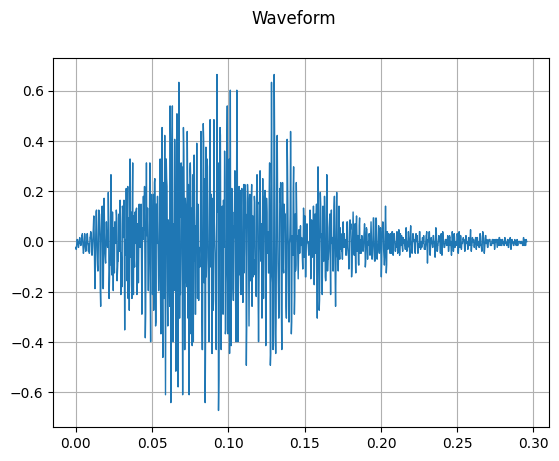

In [14]:
plot_waveform(*audio)

In [15]:
dog_and_cat_dataset = pd.concat((dog_dataset, cat_dataset))
standard_frame_rate = dog_and_cat_dataset["frame_rate"].min()
max_duration_ms = math.ceil(dog_and_cat_dataset["duration"].max() * 1000)

In [16]:
def audio_formatting(path, standard_frame_rate, max_duration_ms):
    audio = torchaudio.load(path)
    mono_audio = stereo_to_mono(audio)
    resampled_mono_audio = resample(mono_audio, standard_frame_rate)
    resampled_resized_mono_audio = resize_with_silence(resampled_mono_audio, max_duration_ms)

    return resampled_resized_mono_audio

dog_and_cat_dataset["audio"] = dog_and_cat_dataset["path"].apply(
    lambda path: audio_formatting(path, standard_frame_rate, max_duration_ms)
)
dog_and_cat_training_data = dog_and_cat_dataset[["name", "class", "audio"]].reset_index(drop=True)

In [17]:
n_fft = 2048
win_length = None
hop_length = 512
n_mels = 256
n_mfcc = 256

mfcc_transform = torchaudio.transforms.MFCC(
    sample_rate=standard_frame_rate,
    n_mfcc=n_mfcc,
    melkwargs={
        "n_fft": n_fft,
        "n_mels": n_mels,
        "hop_length": hop_length,
        "mel_scale": "htk",
    },
)

In [18]:
mfcc = mfcc_transform(dog_and_cat_dataset["audio"].iloc[2][0])

In [19]:
mfcc[0].shape

torch.Size([256, 64])

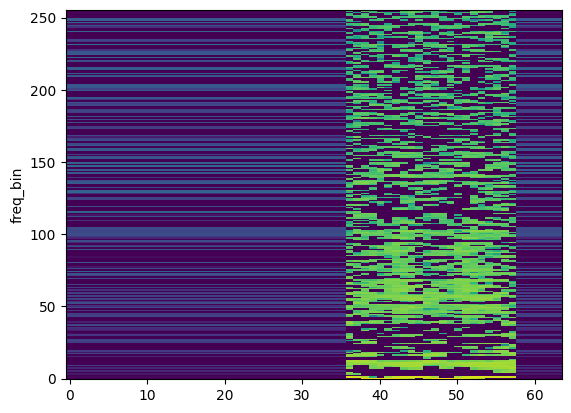

In [20]:
plot_spectrogram(mfcc[0])

In [21]:
dog_and_cat_training_data["mfcc"] = dog_and_cat_training_data["audio"].apply(lambda x: mfcc_transform(x[0])[0])

In [22]:
dog_cat_training = dog_and_cat_training_data[["name", "class", "mfcc"]]

In [23]:
dog_cat_training.loc[dog_cat_training["class"] == "cat", "class"] = 0
dog_cat_training.loc[dog_cat_training["class"] == "dog", "class"] = 1

In [24]:
dog_cat_write_copy = dog_cat_training.copy()
dog_cat_write_copy["mfcc"] = dog_cat_write_copy["mfcc"].apply(lambda x: x.tolist())
dog_cat_write_copy.to_csv("dog_cat_training.csv", index=False)

In [25]:
dog_cat_training = pd.read_csv("dog_cat_training.csv")
dog_cat_training["mfcc"] = dog_cat_training["mfcc"].apply(lambda x: torch.tensor(ast.literal_eval(x)))

In [41]:
dog_cat_training

,name,class,mfcc
0,Dog_1.wav,1,"[[tensor(-545.3198), tensor(-545.3198), tensor..."
1,Dog_10.wav,1,"[[tensor(-549.0175), tensor(-549.0175), tensor..."
2,Dog_11.wav,1,"[[tensor(-695.6265), tensor(-695.6265), tensor..."
3,Dog_12.wav,1,"[[tensor(-686.3892), tensor(-686.3892), tensor..."
4,Dog_13.wav,1,"[[tensor(-699.1985), tensor(-699.1985), tensor..."
...,...,...,...
95,Cat_50.wav,0,"[[tensor(-504.8282), tensor(-504.8282), tensor..."
96,Cat_6.wav,0,"[[tensor(-669.6407), tensor(-669.6407), tensor..."
97,Cat_7.wav,0,"[[tensor(-625.5564), tensor(-625.5564), tensor..."
98,Cat_8.wav,0,"[[tensor(-828.6452), tensor(-828.6452), tensor..."


In [477]:
# Custom CNN architecutre
class CNNNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        # conv blocks / flatten / linear / softmax
        self.conv1 = nn.Sequential(
            nn.Conv2d(
                in_channels=1,
                out_channels=16,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.ReLU(),
            nn.BatchNorm2d(16),
            nn.MaxPool2d(kernel_size=2),
            nn.Dropout(p=0.2)
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(
                in_channels=16,
                out_channels=32,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.ReLU(),
            nn.BatchNorm2d(32),
            nn.MaxPool2d(kernel_size=2),
            nn.Dropout(p=0.2)
        )
        self.conv3 = nn.Sequential(
            nn.Conv2d(
                in_channels=32,
                out_channels=48,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.ReLU(),
            nn.BatchNorm2d(48),
            nn.MaxPool2d(kernel_size=2),
            nn.Dropout(p=0.2)
        )
        self.conv4 = nn.Sequential(
            nn.Conv2d(
                in_channels=48,
                out_channels=64,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(kernel_size=2),
            nn.Dropout(p=0.2)
        )
        self.flatten = nn.Flatten()
        self.linear = nn.Linear(4096, 2)
        self.batchnorm = nn.BatchNorm1d(num_features=2)
        self.softmax = nn.Softmax(dim=1)

    def forward(self, input_data):
        x = self.conv1(input_data)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.flatten(x)
        logits = self.linear(x)
        logits = self.batchnorm(logits)
        predictions = self.softmax(logits)
        return predictions

In [488]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import models
import numpy as np
from sklearn.model_selection import train_test_split
import pandas as pd

# Assuming your DataFrame is called dog_cat_training
# dog_cat_training should have 'mfcc' (MFCC feature matrix) and 'class' (labels)

# Device setup
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

# Define the Dataset class
class AudioDataset(torch.utils.data.Dataset):
    def __init__(self, mfccs, labels):
        self.mfccs = mfccs
        self.labels = labels

    def __len__(self):
        return len(self.mfccs)

    def __getitem__(self, idx):
        mfcc = torch.tensor(self.mfccs[idx], dtype=torch.float32)  # MFCC is typically 2D: (n_mfcc, n_frames)
        label = torch.tensor(self.labels[idx], dtype=torch.long)  # Ensure label is an integer type
        return mfcc, label

# Prepare data
mfccs = np.array(dog_cat_training['mfcc'].tolist())  # Convert list of arrays to a numpy array
labels = np.array(dog_cat_training['class'].tolist())

# Split data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(mfccs, labels, test_size=0.2, random_state=42)

# Create PyTorch datasets
train_dataset = AudioDataset(X_train, y_train)
val_dataset = AudioDataset(X_val, y_val)

# Create PyTorch dataloaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# Create custom CNN and send to device
cnn = CNNNetwork().to(device)

# Loss function and optimizer
criterion = nn.CrossEntropyLoss()  # Suitable for multi-class classification
optimizer = optim.Adam(cnn.parameters(), lr=0.001)

# Training loop
num_epochs = 30
for epoch in range(num_epochs):
    cnn.train()  # Set model to training mode
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in train_loader:
        # Add the channel dimension (1 channel, like grayscale)
        inputs = inputs.unsqueeze(1).to(device)  # Shape: (batch_size, 1, 256, 64)
        labels = labels.to(device)

        optimizer.zero_grad()  # Zero the parameter gradients

        # Forward pass
        outputs = cnn(inputs)

        loss = criterion(outputs, labels)  # Calculate loss
        loss.backward()  # Backward pass
        optimizer.step()  # Update weights

        running_loss += loss.item()

        # Calculate accuracy
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_accuracy = 100 * correct / total

    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}, Accuracy: {epoch_accuracy:.2f}%")

    # Validation loop (optional)
    if (epoch+1) % 5 == 0:
        cnn.eval()  # Set model to evaluation mode
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():  # No need to calculate gradients during validation
            for inputs, labels in val_loader:
                inputs = inputs.unsqueeze(1).to(device)  # Add channel dimension (1 channel)
                labels = labels.to(device)
                outputs = cnn(inputs)
                loss = criterion(outputs, labels)

                val_loss += loss.item()

                _, predicted = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        val_loss = val_loss / len(val_loader)
        val_accuracy = 100 * val_correct / val_total
        print(f"Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_accuracy:.2f}%")

Epoch 1/30, Loss: 0.7128, Accuracy: 55.00%
Epoch 2/30, Loss: 0.6502, Accuracy: 67.50%
Epoch 3/30, Loss: 0.6299, Accuracy: 67.50%
Epoch 4/30, Loss: 0.6014, Accuracy: 66.25%
Epoch 5/30, Loss: 0.6003, Accuracy: 71.25%
Validation Loss: 0.6343, Validation Accuracy: 65.00%
Epoch 6/30, Loss: 0.5474, Accuracy: 75.00%
Epoch 7/30, Loss: 0.4885, Accuracy: 88.75%
Epoch 8/30, Loss: 0.5593, Accuracy: 80.00%
Epoch 9/30, Loss: 0.4967, Accuracy: 86.25%
Epoch 10/30, Loss: 0.5004, Accuracy: 85.00%
Validation Loss: 0.6190, Validation Accuracy: 80.00%
Epoch 11/30, Loss: 0.5080, Accuracy: 83.75%
Epoch 12/30, Loss: 0.5038, Accuracy: 83.75%
Epoch 13/30, Loss: 0.4604, Accuracy: 90.00%
Epoch 14/30, Loss: 0.4854, Accuracy: 86.25%
Epoch 15/30, Loss: 0.5009, Accuracy: 83.75%
Validation Loss: 0.5801, Validation Accuracy: 80.00%
Epoch 16/30, Loss: 0.4739, Accuracy: 86.25%
Epoch 17/30, Loss: 0.4571, Accuracy: 92.50%
Epoch 18/30, Loss: 0.4620, Accuracy: 92.50%
Epoch 19/30, Loss: 0.4703, Accuracy: 90.00%
Epoch 20/30, L

In [551]:
processed_meow = audio_formatting("test_data/cat5.wav", standard_frame_rate, max_duration_ms)

In [552]:
meow_mfcc = mfcc_transform(processed_meow[0])

In [553]:
meow_mfcc = meow_mfcc.unsqueeze(0).unsqueeze(0).to(device)

In [554]:
with torch.no_grad():
    output = cnn(meow_mfcc[0])

_, predicted_class = torch.max(output, 1)

In [555]:
"cat" if predicted_class == 0 else "dog"

'cat'

In [494]:
torch.save(cnn, "cat_dog_model.pth")